## XGBoost

In this notebook, we perform a comprehensive grid search to find the best configuration for the **XGBoost Classifier**. The experiment combines **hyperparameter tuning** with **incremental feature selection** based on a pre-computed feature importance ranking.

In [ ]:
import os
import sys

sys.path.append(os.path.abspath("../"))

from src.evaluation import *
from src.visualization import plot_metric_surface

import warnings
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBClassifier
import pandas as pd

warnings.filterwarnings("ignore")

In [ ]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking_xgb.csv")
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

#### What is being tested below:
1. **Model Hyperparameters (`PARAM_GRID`)**:
   * `max_depth`: `[3, 5, 7]` — Controls the depth of the trees.
   * `learning_rate`: `[0.03, 0.05, 0.1]` — The step size shrinkage.
   * `n_estimators`: `[100, 300]` — The number of trees to build.

2. **Incremental Feature Selection (`K_VALUES`)**:
   * The loop tests models built with the top **1 to 20** features, sorted sequentially by their pre-calculated importance ranking (`xgb_rank`).

3. **Evaluation Thresholds (`TOP_N_VALUES`)**:
   * Evaluates performance metrics across different subsets of top predictions `[50, 100, 250, 500, 750, 900, 950, 1000]` to optimize business-driven targets.

#### Process:
* The nested loops iterate through every combination of parameters.
* A cross-validation evaluation function (`cross_val_eval`) runs for each configuration.
* All parameters and performance metrics are saved to `final_results` dataframe.

In [11]:
MODEL_CONFIGS = {
    "xgboost": XGBClassifier
}

PARAM_GRID = {
    "xgboost": {
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "n_estimators": [100, 300],
    }
}

K_VALUES = range(1, 21)

TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]
all_results = []

sorted_features = feature_importance_df.sort_values("xgb_rank")["feature"].values
print(f"First feature is: {sorted_features[0]}")

for model_name, model_class in MODEL_CONFIGS.items():

    print(f"\nRunning model: {model_name}")

    grid = PARAM_GRID[model_name]

    for max_depth in grid["max_depth"]:
        for learning_rate in grid["learning_rate"]:
            for n_estimators in grid["n_estimators"]:

                print(
                    f"depth={max_depth}, "
                    f"lr={learning_rate}, "
                    f"trees={n_estimators}, "
                )

                for k in K_VALUES:

                    selected_features = sorted_features[:k]
                    X_sel = x_train_scaled[selected_features]

                    model = model_class(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        colsample_bytree=0.8,
                        eval_metric="logloss",
                        random_state=42
                    )

                    for t in TOP_N_VALUES:
                        summary = cross_val_eval(
                            model=model,
                            X=X_sel,
                            y=y_train,
                            n_features=k,
                            model_name=(
                                f"{model_name}_"
                                f"d{max_depth}_"
                                f"lr{learning_rate}_"
                                f"n{n_estimators}_"
                                f"k{k}"
                            ),
                            top_n=t, scaled_features=True
                        )

                        summary["model_type"] = model_name
                        summary["max_depth"] = max_depth
                        summary["learning_rate"] = learning_rate
                        summary["n_estimators"] = n_estimators
                        summary["k"] = k
                        summary["top_n"] = t

                        all_results.append(summary)

final_results = pd.DataFrame(all_results)

First feature is: V224

Running model: xgboost
depth=3, lr=0.03, trees=100, 
depth=3, lr=0.03, trees=300, 
depth=3, lr=0.05, trees=100, 
depth=3, lr=0.05, trees=300, 
depth=3, lr=0.1, trees=100, 
depth=3, lr=0.1, trees=300, 
depth=5, lr=0.03, trees=100, 
depth=5, lr=0.03, trees=300, 
depth=5, lr=0.05, trees=100, 
depth=5, lr=0.05, trees=300, 
depth=5, lr=0.1, trees=100, 
depth=5, lr=0.1, trees=300, 
depth=7, lr=0.03, trees=100, 
depth=7, lr=0.03, trees=300, 
depth=7, lr=0.05, trees=100, 
depth=7, lr=0.05, trees=300, 
depth=7, lr=0.1, trees=100, 
depth=7, lr=0.1, trees=300, 


In [12]:
final_results.sort_values(by="score", ascending=False).head(20)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,...,profit_std,score_std,model,threshold,top_n,model_type,max_depth,learning_rate,n_estimators,k
367,0.6012,0.747,0.300241,0.428325,1241.0,1001.0,6,0.008044,0.020187,0.008084,...,60.559888,60.559888,xgboost_d3_lr0.05_n100_k6,None,1000,xgboost,3,0.05,100,6
47,0.6008,0.746,0.299836,0.427749,1238.0,998.0,6,0.005541,0.014748,0.005706,...,44.243644,44.243644,xgboost_d3_lr0.03_n100_k6,None,1000,xgboost,3,0.03,100,6
527,0.5980,0.739,0.297026,0.423738,1217.0,977.0,6,0.003536,0.008944,0.003559,...,26.832816,26.832816,xgboost_d3_lr0.05_n300_k6,None,1000,xgboost,3,0.05,300,6
351,0.5868,0.711,0.285771,0.407683,1133.0,973.0,4,0.011032,0.027704,0.011095,...,83.111371,83.111371,xgboost_d3_lr0.05_n100_k4,None,1000,xgboost,3,0.05,100,4
207,0.5964,0.735,0.295417,0.421444,1205.0,965.0,6,0.006189,0.015811,0.006265,...,47.434165,47.434165,xgboost_d3_lr0.03_n300_k6,None,1000,xgboost,3,0.03,300,6
359,0.5908,0.721,0.289788,0.413414,1163.0,963.0,5,0.008643,0.022192,0.008775,...,66.577023,66.577023,xgboost_d3_lr0.05_n100_k5,None,1000,xgboost,3,0.05,100,5
199,0.5904,0.720,0.289384,0.412838,1160.0,960.0,5,0.010164,0.026220,0.010344,...,78.660664,78.660664,xgboost_d3_lr0.03_n300_k5,None,1000,xgboost,3,0.03,300,5
511,0.5848,0.706,0.283765,0.404820,1118.0,958.0,4,0.009524,0.023292,0.009471,...,69.874888,69.874888,xgboost_d3_lr0.05_n300_k4,None,1000,xgboost,3,0.05,300,4
687,0.5952,0.732,0.294210,0.419723,1196.0,956.0,6,0.008526,0.021679,0.008622,...,65.038450,65.038450,xgboost_d3_lr0.1_n100_k6,None,1000,xgboost,3,0.10,100,6
671,0.5844,0.705,0.283360,0.404243,1115.0,955.0,4,0.008620,0.021506,0.008643,...,64.517440,64.517440,xgboost_d3_lr0.1_n100_k4,None,1000,xgboost,3,0.10,100,4


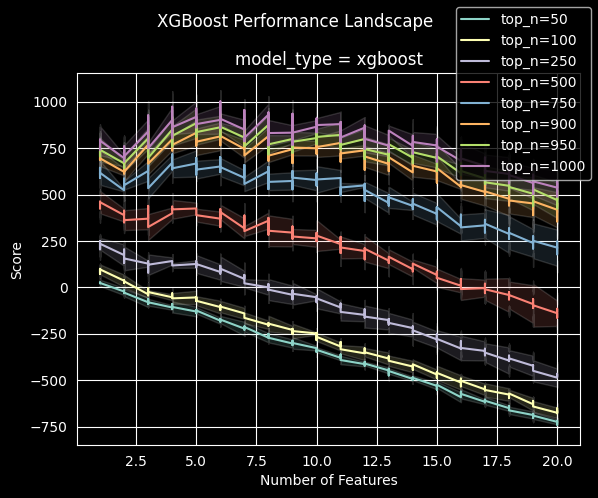

In [16]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="XGBoost Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)

The plot illustrates that the business score increases drastically as the `top_n` parameter increases, reaching its highest, optimal values for the `top_n=1000` line. It also confirms again that regardless of the chosen prediction threshold, the model achieves the best results using around 4–6 features.

#### XGBoost - using MI + XGBoost feature importance - experiment 2

1. **Different Feature Ranking**: A baseline XGBoost model is trained directly to dynamically calculate and sort features by importance (`xgb_features`).
2. **Expanded Feature Range (`K_VALUES`)**: The feature selection threshold has been increased to test from the top **1 up to 30** features (previously up to 20).

*The hyperparameter grid (`max_depth`, `learning_rate`, `n_estimators`) and `TOP_N_VALUES` remain the same.*

In [ ]:
xgb_for_ranking = XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    eval_metric="logloss",
    random_state=42
)

xgb_for_ranking.fit(x_train_scaled, y_train)

xgb_importance = pd.Series(
    xgb_for_ranking.feature_importances_,
    index=x_train_scaled.columns
)

xgb_features = (
    xgb_importance
    .sort_values(ascending=False)
    .index
    .tolist()
)


MODEL_CONFIGS = {
    "xgboost": XGBClassifier
}

PARAM_GRID = {
    "xgboost": {
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "n_estimators": [100, 300],
    }
}


K_VALUES = range(1, 31)
TOP_N_VALUES = [50, 100, 250, 500, 750, 900, 950, 1000]


all_results = []



for model_name, model_class in MODEL_CONFIGS.items():

    grid = PARAM_GRID[model_name]

    for max_depth in grid["max_depth"]:
        for learning_rate in grid["learning_rate"]:
            for n_estimators in grid["n_estimators"]:

                print(
                    f"{model_name} | "
                    f"d={max_depth} "
                    f"lr={learning_rate} "
                    f"n={n_estimators}"
                )

                for k in K_VALUES:

                    selected_features = xgb_features[:k]

                    X_sel = x_train_scaled[selected_features]

                    model = model_class(
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        colsample_bytree=0.8,
                        eval_metric="logloss",
                        random_state=42
                    )

                    for t in TOP_N_VALUES:
                        summary = cross_val_eval(
                            model=model,
                            X=X_sel,
                            y=y_train,
                            n_features=k,
                            model_name=(
                                f"{model_name}_"
                                f"d{max_depth}_"
                                f"lr{learning_rate}_"
                                f"n{n_estimators}_"
                                f"k{k}"
                            ),
                            top_n=t, scaled_features=True
                        )

                        summary["model_type"] = model_name
                        summary["max_depth"] = max_depth
                        summary["learning_rate"] = learning_rate
                        summary["n_estimators"] = n_estimators
                        summary["k"] = k
                        summary["top_n"] = t

                        all_results.append(summary)


final_results_xg = pd.DataFrame(all_results)

xgboost | d=3 lr=0.03 n=100
xgboost | d=3 lr=0.03 n=300
xgboost | d=3 lr=0.05 n=100
xgboost | d=3 lr=0.05 n=300
xgboost | d=3 lr=0.1 n=100
xgboost | d=3 lr=0.1 n=300
xgboost | d=5 lr=0.03 n=100
xgboost | d=5 lr=0.03 n=300
xgboost | d=5 lr=0.05 n=100
xgboost | d=5 lr=0.05 n=300
xgboost | d=5 lr=0.1 n=100
xgboost | d=5 lr=0.1 n=300
xgboost | d=7 lr=0.03 n=100
xgboost | d=7 lr=0.03 n=300
xgboost | d=7 lr=0.05 n=100
xgboost | d=7 lr=0.05 n=300
xgboost | d=7 lr=0.1 n=100
xgboost | d=7 lr=0.1 n=300


In [6]:
final_results_xg.sort_values(by="score", ascending=False).head(20)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,...,profit_std,score_std,model,threshold,top_n,model_type,max_depth,learning_rate,n_estimators,k
35,0.6056,0.758,0.304663,0.434633,1274.0,1034.0,6,0.008325,0.020797,0.008353,...,62.389903,62.389903,xgboost_d3_lr0.03_n300_k6,None,1000,xgboost,3,0.03,300,6
5,0.6040,0.754,0.303050,0.432335,1262.0,1022.0,6,0.011467,0.029240,0.011604,...,87.721149,87.721149,xgboost_d3_lr0.03_n100_k6,None,1000,xgboost,3,0.03,100,6
125,0.6032,0.752,0.302249,0.431191,1256.0,1016.0,6,0.009628,0.024393,0.009715,...,73.177866,73.177866,xgboost_d3_lr0.1_n100_k6,None,1000,xgboost,3,0.10,100,6
95,0.6028,0.751,0.301848,0.430618,1253.0,1013.0,6,0.009039,0.022749,0.009096,...,68.245879,68.245879,xgboost_d3_lr0.05_n300_k6,None,1000,xgboost,3,0.05,300,6
65,0.6024,0.750,0.301446,0.430045,1250.0,1010.0,6,0.008081,0.020310,0.008129,...,60.930288,60.930288,xgboost_d3_lr0.05_n100_k6,None,1000,xgboost,3,0.05,100,6
36,0.6060,0.759,0.305064,0.435206,1277.0,997.0,7,0.009513,0.023822,0.009555,...,71.466775,71.466775,xgboost_d3_lr0.03_n300_k7,None,1000,xgboost,3,0.03,300,7
305,0.6000,0.744,0.299030,0.426600,1232.0,992.0,6,0.010794,0.027704,0.010954,...,83.111371,83.111371,xgboost_d5_lr0.1_n100_k6,None,1000,xgboost,5,0.10,100,6
126,0.6052,0.757,0.304261,0.434060,1271.0,991.0,7,0.009039,0.022528,0.009063,...,67.583282,67.583282,xgboost_d3_lr0.1_n100_k7,None,1000,xgboost,3,0.10,100,7
186,0.6052,0.757,0.304259,0.434058,1271.0,991.0,7,0.012637,0.031741,0.012709,...,95.223421,95.223421,xgboost_d5_lr0.03_n100_k7,None,1000,xgboost,5,0.03,100,7
6,0.6048,0.756,0.303853,0.433480,1268.0,988.0,7,0.013103,0.033429,0.013263,...,100.287088,100.287088,xgboost_d3_lr0.03_n100_k7,None,1000,xgboost,3,0.03,100,7


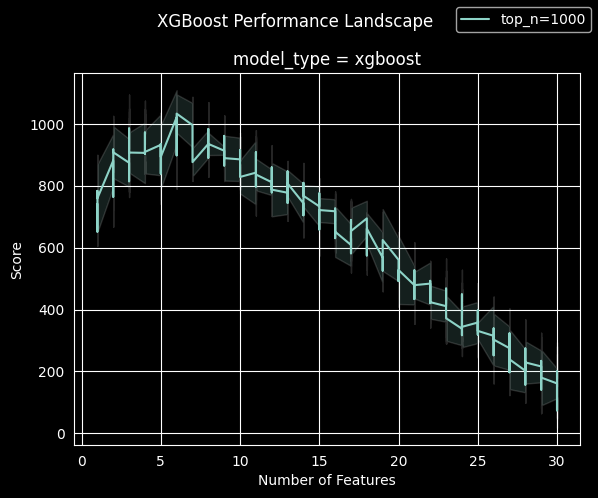

In [17]:
plot_metric_surface(
    df=final_results_xg,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="XGBoost Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)

The plot shows that the model reaches its peak performance (Score over 1000) when selecting around 6 key features derived from the ranking. Adding more features beyond this number leads to the lower score, meaning that further expanding the model only introduces unnecessary informational noise into the classifier.